# Kolkata Sales (Realestate) Report

## Pre Requisite

In [2]:

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [3]:
df= pd.read_csv('real.csv')
df.head()

,Unnamed: 0,Name,Area,Furnishing,Transaction,Status,Price
0,0,4 BHK Apartment for Sale in Sugam Morya,1850 sqft,Unfurnished,Resale,Ready to Move,₹2.38 Cr
1,1,2 BHK Apartment for Sale in Regent Park Kolkata,525 sqft,Unfurnished,Resale,Ready to Move,₹32 Lac
2,2,2 BHK Apartment for Sale in Parvati Garden,705 sqft,Unfurnished,Resale,Ready to Move,₹32 Lac
3,3,3 BHK Apartment for Sale in Multicon Estelle,1612 sqft,Unfurnished,Resale,Ready to Move,₹2.25 Cr
4,4,2 BHK Apartment for Sale in Golpark Cooperativ...,980 sqft,Semi-Furnished,Resale,Ready to Move,₹50 Lac


# Data Correction

## By Area

In [4]:
df['area'] = pd.to_numeric(df['Area'].str.replace(r'[^\d.]', '', regex=True), errors='coerce')
df['area'].fillna(np.mean(df['area']))
df.head()

,Unnamed: 0,Name,Area,Furnishing,Transaction,Status,Price,area
0,0,4 BHK Apartment for Sale in Sugam Morya,1850 sqft,Unfurnished,Resale,Ready to Move,₹2.38 Cr,1850
1,1,2 BHK Apartment for Sale in Regent Park Kolkata,525 sqft,Unfurnished,Resale,Ready to Move,₹32 Lac,525
2,2,2 BHK Apartment for Sale in Parvati Garden,705 sqft,Unfurnished,Resale,Ready to Move,₹32 Lac,705
3,3,3 BHK Apartment for Sale in Multicon Estelle,1612 sqft,Unfurnished,Resale,Ready to Move,₹2.25 Cr,1612
4,4,2 BHK Apartment for Sale in Golpark Cooperativ...,980 sqft,Semi-Furnished,Resale,Ready to Move,₹50 Lac,980


## By BHK

In [5]:
def extract_bhk(name):
    x=name.split()
    if "1" in x:
        return 1
    elif "2" in x:
        return 2
    elif "3" in x:
        return 3
    elif "4" in x:
        return 4
    elif "5" in x:
        return 5
    elif "6" in x:
        return 6
    elif "7" in x:
        return 7
    elif "8" in x:
        return 8
    elif "9" in x:
        return 9
    elif "10" in x:
        return 10
    else:
        return 0
def cor(x):
    if(x==0):
        return int(np.mean(df['BHK']))
    return x

df['BHK'] = df['Name'].apply(extract_bhk)
df['BHK']= df['BHK'].apply(cor)
df.head()

,Unnamed: 0,Name,Area,Furnishing,Transaction,Status,Price,area,BHK
0,0,4 BHK Apartment for Sale in Sugam Morya,1850 sqft,Unfurnished,Resale,Ready to Move,₹2.38 Cr,1850,4
1,1,2 BHK Apartment for Sale in Regent Park Kolkata,525 sqft,Unfurnished,Resale,Ready to Move,₹32 Lac,525,2
2,2,2 BHK Apartment for Sale in Parvati Garden,705 sqft,Unfurnished,Resale,Ready to Move,₹32 Lac,705,2
3,3,3 BHK Apartment for Sale in Multicon Estelle,1612 sqft,Unfurnished,Resale,Ready to Move,₹2.25 Cr,1612,3
4,4,2 BHK Apartment for Sale in Golpark Cooperativ...,980 sqft,Semi-Furnished,Resale,Ready to Move,₹50 Lac,980,2


## By Price

In [6]:
def nu (x):
  s=""
  for i in x:
    if i.isdigit():
      s+=i
    elif i=='.':
      s+=i
  if "Lac" in x:
    return float(s)*100000
  if "Cr" in x:
    return float(s)*10000000
df['price']=df['Price'].apply(nu)
df.head()


,Unnamed: 0,Name,Area,Furnishing,Transaction,Status,Price,area,BHK,price
0,0,4 BHK Apartment for Sale in Sugam Morya,1850 sqft,Unfurnished,Resale,Ready to Move,₹2.38 Cr,1850,4,23800000.0
1,1,2 BHK Apartment for Sale in Regent Park Kolkata,525 sqft,Unfurnished,Resale,Ready to Move,₹32 Lac,525,2,3200000.0
2,2,2 BHK Apartment for Sale in Parvati Garden,705 sqft,Unfurnished,Resale,Ready to Move,₹32 Lac,705,2,3200000.0
3,3,3 BHK Apartment for Sale in Multicon Estelle,1612 sqft,Unfurnished,Resale,Ready to Move,₹2.25 Cr,1612,3,22500000.0
4,4,2 BHK Apartment for Sale in Golpark Cooperativ...,980 sqft,Semi-Furnished,Resale,Ready to Move,₹50 Lac,980,2,5000000.0


# Statistical Summary


## By Area

In [7]:
df['area'].describe()

count    3000.000000
mean     1143.171667
std       783.439505
min       268.000000
25%       705.000000
50%       928.000000
75%      1612.000000
max      4400.000000
Name: area, dtype: float64

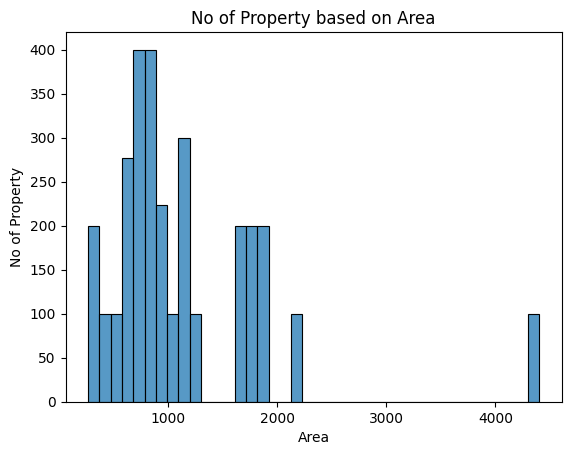

In [8]:
sns.histplot(df['area'],bins=40)
plt.title('No of Property based on Area')
plt.ylabel('No of Property')
plt.xlabel('Area')
plt.show()

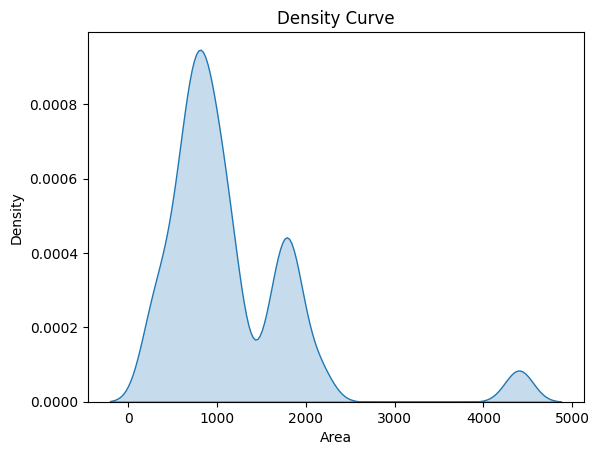

In [9]:
sns.kdeplot(df['area'],fill=True)
plt.title('Density Curve')
plt.xlabel('Area')
plt.show()

### By this we can conclude that most people prefer property in the range of 900-1200 BHK. So the real estate company must focus on building more properties within this range.

## By BHK

In [10]:
df['BHK'].describe()

count    3000.000000
mean        2.674333
std         0.976350
min         1.000000
25%         2.000000
50%         3.000000
75%         3.000000
max         6.000000
Name: BHK, dtype: float64

In [11]:
df_bhk=df.groupby('BHK').size().reset_index()
df_bhk.columns=['BHK','Count']
df_bhk.head()

,BHK,Count
0,1,100
1,2,1377
2,3,1223
3,4,100
4,5,100


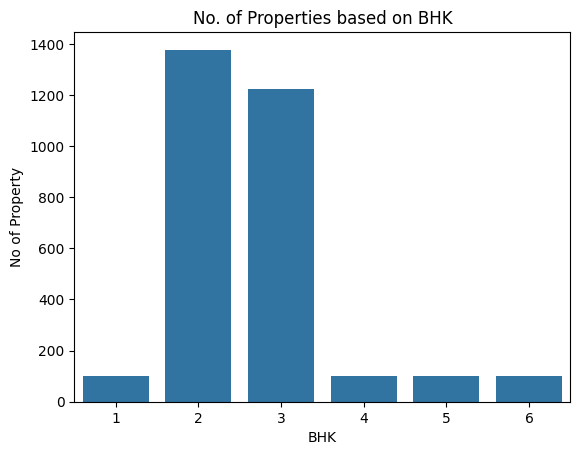

In [12]:
sns.barplot(x='BHK',y='Count',data=df_bhk)
plt.title('No. of Properties based on BHK')
plt.ylabel('No of Property')
plt.show()

### So from this Bar Graph we can coclude that  most people are interested in 2 or 3 BHK flats so real estat company must focus on building more 2 BHK flats that will ensure revenue

In [13]:
df_Bhk = df.groupby('BHK')['price'].mean().reset_index()
df_Bhk.head()

,BHK,price
0,1,1.500000e+06
1,2,7.744009e+06
2,3,8.204497e+06
3,4,2.380000e+07
4,5,1.450000e+07


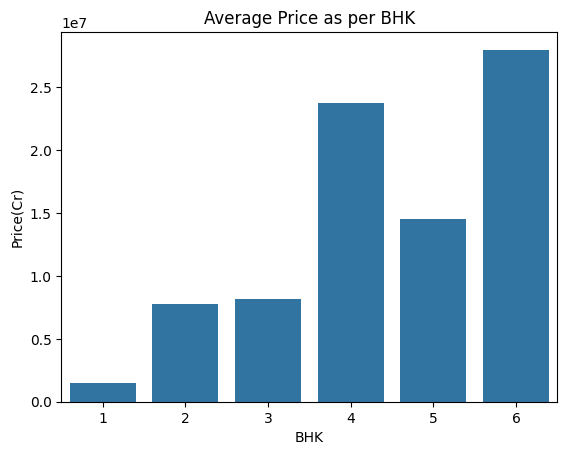

In [14]:
sns.barplot(x='BHK', y='price', data=df_Bhk)
plt.ylabel('Price(Cr)')
plt.title('Average Price as per BHK')
plt.show()

#### From this we can see the average price of the properties according to BHK

## By Furnishing

In [15]:
df_fur=df.groupby('Furnishing').size().reset_index()
df_fur.columns=['Furnishing','Count']
df_fur.head()

,Furnishing,Count
0,Furnished,200
1,Semi-Furnished,1200
2,Unfurnished,1223


([<matplotlib.patches.Wedge at 0x113e0c1a0>,
 [Text(1.0685914245762977, 0.2609834617787085, 'Furnished'),
  Text(-0.37257464281318176, 1.0349821909253463, 'Semi-Furnished'),
  Text(0.11637911644695492, -1.0938262664861482, 'Unfurnished')],
 [Text(0.5828680497688896, 0.14235461551565917, '7.624857'),
  Text(-0.20322253244355365, 0.5645357405047343, '45.749142'),
  Text(0.06347951806197541, -0.5966325089924445, '46.626003')])

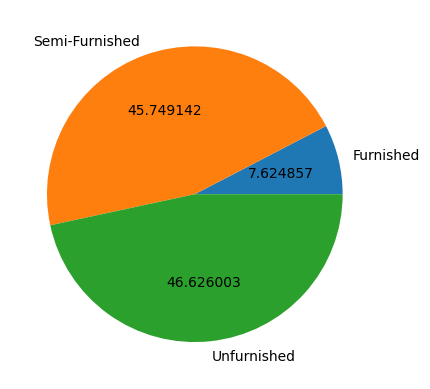

In [ ]:
plt.pie(df_fur['Count'],labels=df_fur['Furnishing'],autopct="%f")
plt.title('Percentage Share of Properties based on Furnishing')
plt.show()

### From this we can conclude most people prefer semi-furnished or unfurnished property

# Final Summary

### Focus on building 2-3 BHK properties with 900-1200 sq ft area in semi-furnished or unfurnished condition for the Kolkata market to maximize demand and revenue.